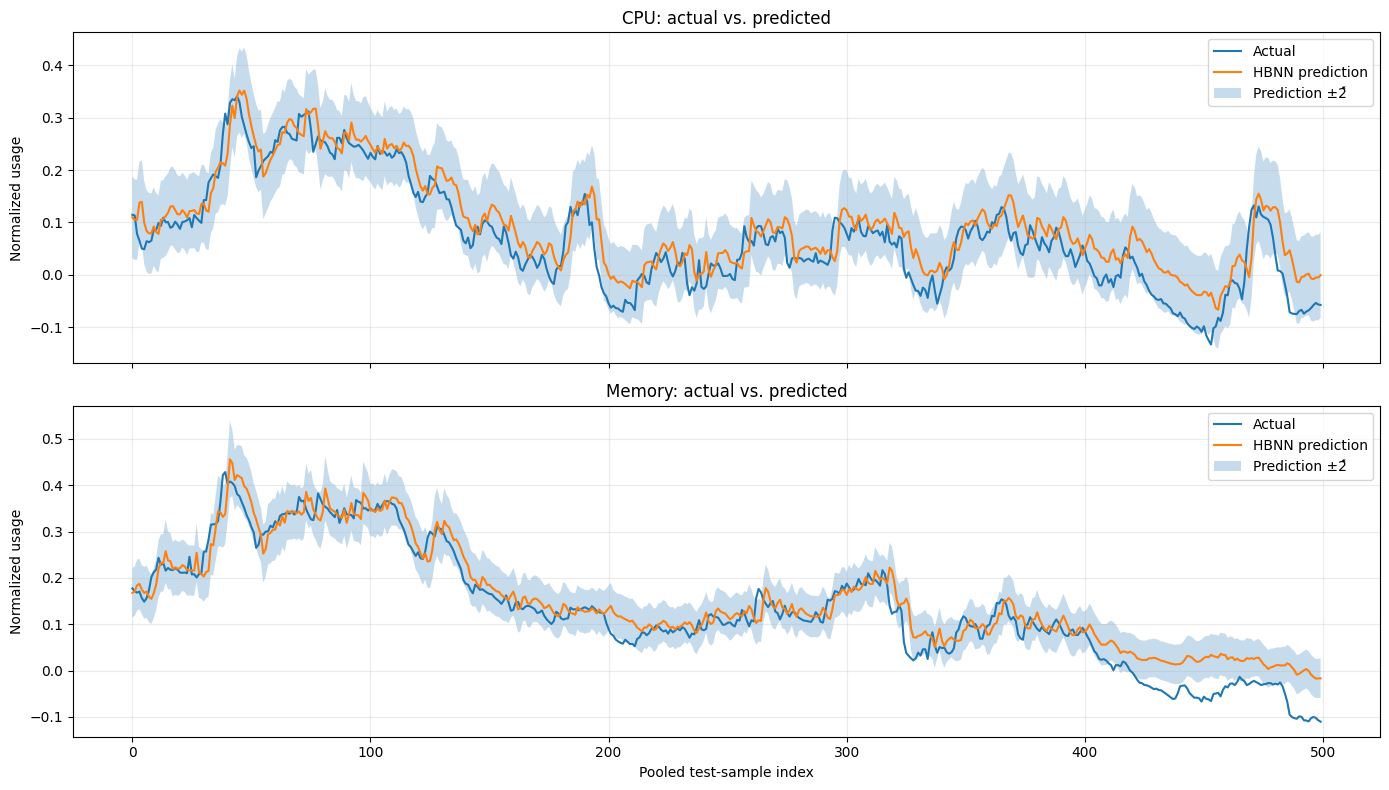

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = Path("/content/results/res")
csv = results / "output_MULTIBIHBNN-w288-h2-ts80-run-0.csv"
df = pd.read_csv(csv)

# Show the last 500 pooled test predictions
sample = df.tail(500).reset_index(drop=True)
x = np.arange(len(sample))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, resource, actual_col, mean_col, std_col in [
    (axes[0], "CPU", "labelsavgcpu", "avgcpu", "stdavgcpu"),
    (axes[1], "Memory", "labelsavgmem", "avgmem", "stdavgmem"),
]:
    mean = sample[mean_col]
    std = sample[std_col]
    ax.plot(x, sample[actual_col], label="Actual")
    ax.plot(x, mean, label="HBNN prediction")
    ax.fill_between(x, mean - 2 * std, mean + 2 * std,
                    alpha=0.25, label="Prediction ±2́̂")
    ax.set_title(f"{resource}: actual vs. predicted")
    ax.set_ylabel("Normalized usage")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Pooled test-sample index")
fig.tight_layout()
fig.savefig(results / "plots" / "forecast_last_500_test_points.png", dpi=150)
plt.show()

In [1]:
import zipfile
from pathlib import Path

zip_path = Path('/content/results.zip')
extract_path = Path('/content/results')

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List and print the extracted files
print("Extracted files:")
for file in extract_path.rglob('*'):
    if file.is_file():
        print(file.relative_to(extract_path))

Extracted files:
__results___files/__results___18_1.png
__results___files/__results___16_0.png
__results___files/__results___18_0.png
res/service_MULTIBIHBNN-w288-h2-ts80.csv
res/errors_MULTIBIHBNN-w288-h2-ts80.csv
res/output_MULTIBIHBNN-w288-h2-ts80-run-0.csv
res/output_train-MULTIBIHBNN-w288-h2-ts80-run-0.csv
res/service_MULTIBIHBNN-w288-h2-ts80-run-0.csv
time/MULTIBIHBNN-w288-h2-ts80inference_time.csv
time/MULTIBIHBNN-w288-h2-ts80-run-0-times.csv
time/MULTIBIHBNN-w288-h2-ts80training_time.csv
res/plots/service_tpr_vs_sr_ts80.png
res/plots/service_confidence_vs_sr_ts80.png
